In [1]:
# utils
import os
import logging
import sys
import json

# manipulação de datas e timezone
import pytz
import datetime as dt

# spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import array, avg, col, concat_ws, expr, collect_list, struct, udf, variance

# pca e redução de dimensionalidade
from pyspark.ml.feature import VectorAssembler, PCA
from pyspark.ml.regression import LinearRegression
from pyspark.ml.linalg import Vectors
from pyspark.ml.stat import Summarizer
from pyspark.ml.feature import StandardScaler
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.sql.types import ArrayType, DoubleType, StructType, StructField

####################
# configurações de timezone
selected_tz = pytz.timezone("America/Sao_Paulo")

#### funções

In [2]:
####################
# configurações de log
class TZFormatter(logging.Formatter):
    def __init__(self, fmt=None, datefmt=None, tz=None):
        super().__init__(fmt=fmt, datefmt=datefmt)
        self.tz = tz or pytz.UTC

    def formatTime(self, record, datefmt=None):
        date_time = dt.datetime.fromtimestamp(record.created, self.tz)
        if datefmt:
            s = date_time.strftime(datefmt)
        else:
            s = date_time.isoformat()
        return s

# função de configuração do log
def configurar_logger(nome_logger):
    logger = logging.getLogger(nome_logger)
    logger.setLevel(logging.INFO)
    logger.propagate = False  # evita envio ao root logger

    if not logger.handlers:
        handler = logging.StreamHandler(sys.stdout)

        # Timezone Brasil (Horário de Brasília)
        #tz_brasil = pytz.timezone("America/Sao_Paulo")

        formatter = TZFormatter(
            fmt='%(asctime)s | %(name)s | %(levelname)s | %(message)s',
            datefmt='%Y-%m-%d %H:%M:%S %z',
            tz=selected_tz
        )
        handler.setFormatter(formatter)
        logger.addHandler(handler)

    return logger

logger_read = configurar_logger("leitura_dados")
logger_ingestion = configurar_logger("ingestao_dados")
logger_transform = configurar_logger("transformacao_dados")
####################

In [3]:
def assemble_features(dataframe, target_col=None):
    """
    Função para montar o vetor de features para PCA e regressão linear
    :param dataframe: DataFrame do Spark
    :param target_col: lista de colunas a serem usadas como features
    :return: DataFrame com coluna 'features' contendo o vetor de features
    """
    numeric_cols = [c for c, dtype in dataframe.dtypes if dtype in ("int", "double", "float")]

    if target_col and target_col in numeric_cols:
        numeric_cols.remove(target_col)
    
    # escapando nomes de colunas problemáticas com crase
    #numeric_cols_escaped = [f"`{c}`" for c in numeric_cols]

    # renomear colunas para nomes "seguros"
    safe_cols = [c.replace(" ", "_").replace("(", "").replace(")", "") for c in numeric_cols]
    for old, new in zip(numeric_cols, safe_cols):
        dataframe = dataframe.withColumnRenamed(old, new)
    logger_transform.info(f"colunas numéricas sanitizadas")

    #assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features")
    assembler = VectorAssembler(inputCols=safe_cols, outputCol="features")
    dataframe_vector = assembler.transform(dataframe)
    logger_transform.info(f"assemble features: colunas numéricas calculadas")

    return dataframe_vector, numeric_cols

def apply_pca(dataframe, n_components=3, target_col=None):
    """
    Aplica PCA para redução de dimensionalidade
    :param dataframe: DataFrame do Spark com coluna 'features'
    :param n_components: número de componentes principais
    :return: DataFrame com coluna 'pca_features'
    """
    logger_transform.info(f"inicializando PCA com {n_components} componentes principais")

    # construção do vetor de features
    dataframe_vector, feature_cols = assemble_features(dataframe, target_col=target_col)

    # aplicando PCA
    pca = PCA(k=n_components, inputCol="features", outputCol="pca_features")
    pca_model = pca.fit(dataframe_vector)

    dataframe_pca = pca_model.transform(dataframe_vector)

    explained_variance = pca_model.explainedVariance.toArray()
    logger_transform.info(f"variância explicada pelos {n_components} componentes principais: {explained_variance}")
    logger_transform.info(f"variância acumulada: {explained_variance.sum()}")
    logger_transform.info("PCA aplicado com sucesso")

    return dataframe_pca


def apply_lasso(dataframe, target_col, regularization=0.1):
    """
    Aplica regressão linear com regularização Lasso (L1)
    :param dataframe: DataFrame do Spark com coluna 'features'
    :param target_col: coluna alvo para regressão
    :param regularization: parâmetro de regularização (lambda)
    :return: modelo treinado e DataFrame com previsões
    """
    logger_transform.info(f"inicializando regressão linear Lasso com regularização {regularization}")

    # construção do vetor de features
    dataframe_vector, feature_cols = assemble_features(dataframe, target_col=target_col)

    # definindo o modelo de regressão linear com Lasso
    lasso = LinearRegression(featuresCol="features", labelCol=target_col, regParam=regularization, elasticNetParam=1.0)

    # treinando o modelo
    lasso_model = lasso.fit(dataframe_vector)

    selected_features = [feature_cols[i] for i, coef in enumerate(lasso_model.coefficients) if coef != 0]

    # métricas do modelo
    mse = lasso_model.summary.meanSquaredError
    r2 = lasso_model.summary.r2
    non_zero = sum([1 for c in lasso_model.coefficients if c != 0])

    # filtrando apenas as colunas selecionadas + target
    selected_cols = selected_features + [target_col] if target_col else selected_features

    logger_transform.info(f"LASSO MSE: {mse}")
    logger_transform.info(f"LASSO R²: {r2}")
    logger_transform.info(f"variáveis selecionadas pelo LASSO: {non_zero} de {len(feature_cols)}")
    logger_transform.info(f"features selecionadas: {selected_features}")

    return dataframe.select(*selected_cols)

#### configurações

In [49]:
####################
##### configurações #####

# metadados variáveis e modelos
from config.variables_config import map_variaveis_meta
from config.models_config import map_modelos_dir

dir_raiz = r"/home/thais/climate-ingestion/climate_data_processing/datasets"

dir_raw = os.path.join(dir_raiz, "raw")
#os.makedirs(dir_raw, exist_ok=True)

dir_trusted = os.path.join(dir_raiz, "trusted")
#os.makedirs(dir_trusted, exist_ok=True)

dir_delivery = os.path.join(dir_raiz, "delivery")

# selecionando a variável
variavel_escolhida = map_variaveis_meta["tas"]

# selecionando o modelo
modelo_escolhido = map_modelos_dir["EC-Earth3"]

# diretório para os datasets nas camadas
dir_modelo = modelo_escolhido["nome_dir"]

# diretório para os datasets | raw
dir_modelo_raw = os.path.join(dir_raw, dir_modelo, variavel_escolhida["variable_id"])
os.makedirs(dir_modelo_raw, exist_ok=True)

# diretório para os datasets | trusted
dir_modelo_trusted = os.path.join(dir_trusted, dir_modelo, variavel_escolhida["variable_id"])
os.makedirs(dir_modelo_trusted, exist_ok=True)

# diretório para os datasets | delivery
dir_modelo_delivery = os.path.join(dir_delivery, dir_modelo, variavel_escolhida["variable_id"])
os.makedirs(dir_modelo_delivery, exist_ok=True)

# parâmetros para a execução do pipeline
source_id = modelo_escolhido["nome"]
experiment_id = variavel_escolhida["experiment_id"]
variable_id=variavel_escolhida["variable_id"]#"tas",
table_id = "Amon"
frequency = "mon"
variant_label = variavel_escolhida["variant_label"]

input_model = source_id
input_experiment_id = experiment_id

# parâmetros da reamostragem espacial, LASSO e PCA
grid_step=5.0
apply_pca_flag=True
apply_lasso_flag=True
lasso_target_strategy="mean"
n_pca_components=5
lasso_regularization=0.1
target_col = f"{variable_id}_{lasso_target_strategy}"

In [31]:
source_id

'EC-Earth3'

#### leitura da camada trusted

In [50]:
# process_variable_delivery_with_algorithms

logger_ingestion.info(f"inicializando pipeline | delivery")
logger_ingestion.info(f"variável: {variable_id} | modelo: {input_model} | experimento: {input_experiment_id}")

# iniciar sessão spark
spark = SparkSession.builder.appName("ClimateDataTest").getOrCreate()

2025-09-08 16:41:04 -0300 | ingestao_dados | INFO | inicializando pipeline | delivery
2025-09-08 16:41:04 -0300 | ingestao_dados | INFO | variável: tas | modelo: EC-Earth3 | experimento: historical


In [7]:
dir_trusted

'/home/thais/climate-ingestion/climate_data_processing/datasets/trusted'

In [55]:
# 1. leitura dos dados da trusted (todos os anos)
logger_ingestion.info(f"lendo todos os arquivos da camada trusted em {dir_modelo_trusted}")
df_trusted = spark.read.parquet(dir_modelo_trusted)

# verificando se há dados
if df_trusted.count() == 0:
    logger_ingestion.warning("nenhum dado encontrado na camada trusted")
    #return

2025-09-08 16:59:52 -0300 | ingestao_dados | INFO | lendo todos os arquivos da camada trusted em /home/thais/climate-ingestion/climate_data_processing/datasets/trusted/ec_earth3/tas


#### visualização de desvio padrão

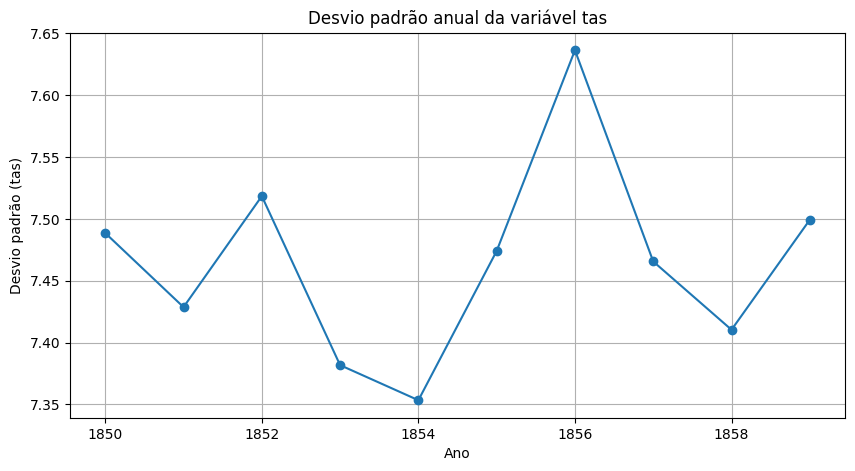

In [56]:
# visualização do desvio padrão anual
# como os valores de tas variam muito pouco, a agregação por média é uma boa alternativa
from pyspark.sql.functions import stddev

# calculando o desvio padrão de 'tas' por ano
df_std_year = (
    df_trusted
    .groupBy("year")
    .agg(stddev(f"{variable_id}").alias(f"{variable_id}_std"))
    .orderBy("year")
)

# convertendo para pandas
df_std_year_pd = df_std_year.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_std_year_pd["year"], df_std_year_pd[f"{variable_id}_std"], marker="o")
plt.xlabel("Ano")
plt.ylabel(f"Desvio padrão ({variable_id})")
plt.title(f"Desvio padrão anual da variável {variable_id}")
plt.grid(True)
plt.show()

<Figure size 1400x600 with 0 Axes>

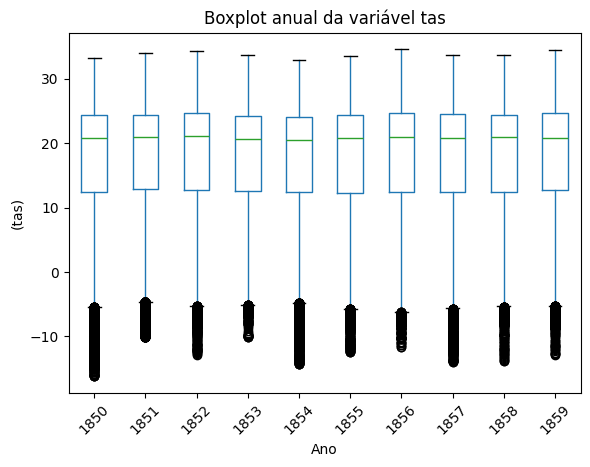

In [57]:
# visualização dos quartis de tas ao longo dos anos
# os valores apresentam mediana deslocada para valores mais altos
# e outliers mais frequentes para temperaturas mais baixas

# selecionando apenas as colunas necessárias
df_tas_year = df_trusted.select("year", f"{variable_id}")

# conversão para pandas
df_tas_year_pd = df_tas_year.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
df_tas_year_pd.boxplot(column=f"{variable_id}", by="year", grid=False)
plt.xlabel("Ano")
plt.ylabel(f"({variable_id})")
plt.title(f"Boxplot anual da variável {variable_id}")
plt.suptitle("")  # Remove o título automático do pandas
plt.xticks(rotation=45)
plt.show()

#### reamostragem espacial

In [38]:
logger_transform.info("instanciando udf para converter o array<double> em DenseVector")

# UDF para converter array<double> em DenseVector
to_vector = udf(lambda x: Vectors.dense(x) if x is not None else Vectors.dense([]))

# reamostragem espacial: arredondando lat/lon para grid_step
logger_transform.info(f"reamostrando para resolução {grid_step}°")

df_resampled = (
    df_trusted
    .withColumn("lat_grid", (col("lat") / grid_step).cast("int") * grid_step)
    .withColumn("lon_grid", (col("lon") / grid_step).cast("int") * grid_step)
    .groupBy("year", "month", "lat_grid", "lon_grid")
    .agg(avg(variable_id).alias(f"{variable_id}_mean"))
)

# calculando a variância do dataframe
#var_df = df_resampled.select(variance(df_resampled.tas_mean).alias("var"))
var_df = df_resampled.select(variance(df_resampled[f"{variable_id}_mean"]).alias("var")) # 

# valor como variável (float)
var_value = var_df.first()["var"]

logger_transform.info(f"reamostragem espacial concluída | {df_resampled.count()} registros | variância: {var_value: .3f}")

# agrupando todos os valores em uma lista
logger_transform.info("agrupando todos os gridpoints em uma única lista por ano/mês")
df_vector_ready = (df_resampled
                   .groupBy("year", "month")
                   .agg(collect_list(f"{variable_id}_mean").alias("grid_list"),
                        collect_list(struct("lat_grid", "lon_grid")).alias("grid_coords"))
                        )
logger_transform.info(f"agrupamento concluído")

# convertendo array<double> → DenseVector
#df_vector = df_vector_ready.withColumn("features", array_to_vector("grid_list"))
df_vector = (df_vector_ready
             .withColumn("features", array_to_vector("grid_list"))
             .withColumn("tas_mean", expr("AGGREGATE(grid_list, 0D, (acc, x) -> acc + x) / size(grid_list)"))
             )

# nomes das colunas de grid
n_features = df_vector.selectExpr("size(grid_list) as n").first()["n"]
feature_names = [f"f{i}" for i in range(n_features)]

# construindo dicionário de mapeamento feature -> (lat, lon)
coords_example = df_vector.select("grid_coords").first()["grid_coords"]
feature_map = {f"f{i}": (row["lat_grid"], row["lon_grid"]) for i, row in enumerate(coords_example)}

# salvar JSON no diretório de saída
'''
feature_map_path = os.path.join(dir_delivery, input_model, variable_id,
                                f"exp={input_experiment_id}",
                                f"pca={apply_pca_flag}",
                                f"lasso={apply_lasso_flag}",
                                "feature_map.json")
'''

feature_map_path = os.path.join(dir_modelo_delivery,
                                f"exp={input_experiment_id}",
                                f"pca={apply_pca_flag}",
                                f"lasso={apply_lasso_flag}",
                                "feature_map.json")


os.makedirs(os.path.dirname(feature_map_path), exist_ok=True)

with open(feature_map_path, "w", encoding="utf-8") as f:
    json.dump(feature_map, f, indent=2)

logger_ingestion.info(f"feature_map salvo em {feature_map_path}")


if apply_lasso_flag or apply_pca_flag:

    if lasso_target_strategy == "mean":
        logger_ingestion.info(f"lasso_target_strategy: {lasso_target_strategy}")
        #df_flatten = df_flatten.withColumn("lasso_target", expr("aggregate(grid_array, 0D, (acc, x) -> acc + x) / size(grid_array)"))
        df_vector = df_vector.withColumn(f"{variable_id}_{lasso_target_strategy}", expr("aggregate(grid_list, 0D, (acc, x) -> acc + x) / size(grid_list)"))
    elif lasso_target_strategy == "max":
        logger_ingestion.info(f"lasso_target_strategy: {lasso_target_strategy}")
        #df_flatten = df_flatten.withColumn("lasso_target", expr("aggregate(grid_array, -1D/0D, (acc, x) -> IF(x > acc, x, acc))"))
        df_vector = df_vector.withColumn(f"{variable_id}_{lasso_target_strategy}", expr("aggregate(grid_list, -1D/0D, (acc, x) -> IF(x > acc, x, acc))"))
    elif lasso_target_strategy == "min":
        logger_ingestion.info(f"lasso_target_strategy: {lasso_target_strategy}")
        #df_flatten = df_flatten.withColumn("lasso_target", expr("aggregate(grid_array, 1D/0D, (acc, x) -> IF(x < acc, x, acc))"))
        df_vector = df_vector.withColumn(f"{variable_id}_{lasso_target_strategy}", expr("aggregate(grid_list, 1D/0D, (acc, x) -> IF(x < acc, x, acc))"))
    else:
        raise ValueError(f"valor inválido para lasso_target_strategy: {lasso_target_strategy}")

logger_transform.info(f"conversão de array<double> para DenseVector concluída")

2025-09-08 16:29:43 -0300 | transformacao_dados | INFO | instanciando udf para converter o array<double> em DenseVector
2025-09-08 16:28:49 -0300 | transformacao_dados | INFO | reamostrando para resolução 5.0°


2025-09-08 16:28:53 -0300 | transformacao_dados | INFO | reamostragem espacial concluída | 15120 registros | variância:  0.000
2025-09-08 16:28:53 -0300 | transformacao_dados | INFO | agrupando todos os gridpoints em uma única lista por ano/mês


2025-09-08 16:28:53 -0300 | transformacao_dados | INFO | agrupamento concluído


2025-09-08 16:28:57 -0300 | ingestao_dados | INFO | feature_map salvo em /home/thais/climate-ingestion/climate_data_processing/datasets/delivery/ec_earth3/pr/exp=historical/pca=True/lasso=True/feature_map.json
2025-09-08 16:28:57 -0300 | ingestao_dados | INFO | lasso_target_strategy: mean
2025-09-08 16:28:57 -0300 | transformacao_dados | INFO | conversão de array<double> para DenseVector concluída


In [42]:
target_col_name = f"{variable_id}_{lasso_target_strategy}"

#### PCA

In [39]:
# aplicando PCA

if apply_pca_flag:
    logger_transform.info(f"inicializando PCA com {n_pca_components} componentes principais")
    pca = PCA(k=n_pca_components, inputCol="features", outputCol="pca_features")
    pca_model = pca.fit(df_vector)
    df_pca = pca_model.transform(df_vector)

    explained_variance = pca_model.explainedVariance.toArray()
    logger_transform.info(f"variância explicada pelos {n_pca_components} componentes principais: {explained_variance}")
    logger_transform.info(f"variância acumulada: {explained_variance.sum()}")

2025-09-08 16:30:23 -0300 | transformacao_dados | INFO | inicializando PCA com 5 componentes principais


2025-09-08 16:29:33 -0300 | transformacao_dados | INFO | variância explicada pelos 5 componentes principais: [0.03834574 0.03467    0.03356765 0.03329615 0.03173079]
2025-09-08 16:29:33 -0300 | transformacao_dados | INFO | variância acumulada: 0.17161033878493448


In [107]:
apply_pca_flag=True
apply_pca_flag

True

In [16]:
from pyspark.ml.feature import VectorSlicer

#### LASSO

In [ ]:
########## não executar ##########
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.linalg import Vectors
import json
import os

def apply_lasso_with_pca(df_vector, df_pca=None, use_pca=False, target_col="tas_mean", regularization=0.1, output_path=None, feature_map_path=None):
    """
    Aplica regressão LASSO com ou sem PCA.
    
    :param df_vector: DataFrame Spark com coluna 'features'
    :param df_pca: DataFrame Spark com coluna 'pca_features' (opcional)
    :param use_pca: se True, aplica LASSO sobre PCA
    :param target_col: coluna alvo
    :param regularization: parâmetro alpha do LASSO
    :param output_path: diretório para salvar o resultado
    :param feature_map_path: caminho do feature_map.json
    :return: DataFrame com variáveis explicativas e selecionadas
    """
    
    # -------------------------------------------------------
    # 1. escolher input (features originais ou PCA)
    # -------------------------------------------------------
    if use_pca:
        logger_transform.info(f"inicializando regressão linear LASSO com regularização {lasso_regularization} | input: DenseArray com PCA")
        df_input = df_pca.withColumnRenamed("pca_features", "features")
    else:
        logger_transform.info(f"inicializando regressão linear LASSO com regularização {lasso_regularization} | input: DenseArray sem PCA")
        df_input = df_vector.withColumnRenamed("features", "features")

    # -------------------------------------------------------
    # 2. ajustar modelo LASSO
    # -------------------------------------------------------
    lasso = LinearRegression(
        featuresCol="features",
        labelCol=target_col,
        elasticNetParam=1.0,  # L1 puro = LASSO
        regParam=regularization
    )

    lasso_model = lasso.fit(df_input)

    # -------------------------------------------------------
    # 3. extrair coeficientes não nulos (seleção de features)
    # -------------------------------------------------------
    logger_transform.info(f"extraindo coeficientes não-nulos (seleção de features)")
    coeffs = lasso_model.coefficients.toArray()
    selected_idx = [i for i, c in enumerate(coeffs) if abs(c) > 1e-6]

    mse = lasso_model.summary.meanSquaredError
    r2 = lasso_model.summary.r2

    logger_transform.info(f"LASSO MSE: {mse: .5f}")
    logger_transform.info(f"LASSO R²: {r2: .5f}")

    # se houver feature_map, traduzir índices → (lat, lon)
    feature_names = []
    if feature_map_path and os.path.exists(feature_map_path):
        logger_transform.info(f"lendo feature map para identificar índices")
        with open(feature_map_path, "r", encoding="utf-8") as f:
            feature_map = json.load(f)
        feature_names = [feature_map[f"f{i}"] for i in selected_idx]
    else:
        logger_transform.info(f"varredura para identificar índices")
        feature_names = [f"f{i}" for i in selected_idx]

    # -------------------------------------------------------
    # 4. montar DataFrame final
    # -------------------------------------------------------
    logger_transform.info(f"construção do dataframe com features selecionadas")
    df_processed = df_input.select("year", "month", target_col, "features")
    
    # converter DenseVector → array<double>
    df_processed = df_processed.withColumn("features_array", vector_to_array("features"))

    # adicionar colunas para features selecionadas
    for idx, name in zip(selected_idx, feature_names):
        #df_processed = df_processed.withColumn(f"sel_{idx}", df_processed.features[idx])
        df_processed = df_processed.withColumn(f"sel_{idx}", df_processed.features_array[idx])

    return df_processed, selected_idx, feature_names

In [40]:
def apply_lasso_with_pca(df_vector, target_col, use_pca=False, regularization=0.1, feature_map_path=None):
    """
    Aplica regressão LASSO com ou sem PCA.
    
    :param df_vector: DataFrame Spark com coluna 'features'
    :param use_pca: se True, aplica LASSO sobre PCA
    :param target_col: label para a coluna output
    :param regularization: parâmetro alpha do LASSO
    :param output_path: diretório para salvar o resultado
    :param feature_map_path: caminho do feature_map.json
    :return: DataFrame com variáveis explicativas e selecionadas
    """
    
    # input (features originais ou PCA)
    if use_pca:
        logger_transform.info(f"inicializando regressão linear LASSO com regularização {regularization} | input: DenseArray com PCA")
        df_input = df_vector.withColumn("features_lasso", col("pca_features"))
    else:
        logger_transform.info(f"inicializando regressão linear LASSO com regularização {regularization} | input: DenseArray sem PCA")
        df_input = df_vector.withColumn("features_lasso", col("features"))

    # ajustando modelo lasso
    lasso = LinearRegression(featuresCol="features_lasso", labelCol=target_col, elasticNetParam=1.0, regParam=regularization)

    lasso_model = lasso.fit(df_input)

    # extraindo coeficientes não nulos (seleção de features)
    logger_transform.info(f"extraindo coeficientes não-nulos (seleção de features)")
    coeffs = lasso_model.coefficients.toArray()
    selected_idx = [i for i, c in enumerate(coeffs) if abs(c) > 1e-6]

    mse = lasso_model.summary.meanSquaredError
    r2 = lasso_model.summary.r2

    logger_transform.info(f"LASSO MSE: {mse: .5f}")
    logger_transform.info(f"LASSO R²: {r2: .5f}")

    # se houver feature_map, traduzir índices → (lat, lon)
    feature_names = []
    if feature_map_path and os.path.exists(feature_map_path):
        logger_transform.info(f"lendo feature map para identificar índices")
        with open(feature_map_path, "r", encoding="utf-8") as f:
            feature_map = json.load(f)
        feature_names = [feature_map[f"f{i}"] for i in selected_idx]
    else:
        logger_transform.info(f"varredura para identificar índices")
        feature_names = [f"f{i}" for i in selected_idx]

    # construindo dataframe final
    logger_transform.info(f"construção do dataframe com features selecionadas")
    df_processed = df_input.select("year", "month", target_col, "features")
    
    # converter DenseVector → array<double>
    df_processed = df_processed.withColumn("features_array", vector_to_array("features"))

    # adicionar colunas para features selecionadas
    for idx, name in zip(selected_idx, feature_names):
        #df_processed = df_processed.withColumn(f"sel_{idx}", df_processed.features[idx])
        df_processed = df_processed.withColumn(f"sel_{idx}", df_processed.features_array[idx])

    return df_processed, selected_idx, feature_names

In [18]:
df_pca.columns

['year',
 'month',
 'grid_list',
 'grid_coords',
 'features',
 'tas_mean',
 'pca_features']

In [43]:
df_lasso, idx, names = apply_lasso_with_pca(
    #df_vector=df_vector,
    df_vector=df_pca,
    use_pca=True,
    target_col=target_col_name,
    regularization=0.1,
    feature_map_path=feature_map_path)


2025-09-08 16:30:36 -0300 | transformacao_dados | INFO | inicializando regressão linear LASSO com regularização 0.1 | input: DenseArray com PCA


2025-09-08 16:31:38 -0300 | transformacao_dados | INFO | extraindo coeficientes não-nulos (seleção de features)
2025-09-08 16:31:38 -0300 | transformacao_dados | INFO | LASSO MSE:  0.00000
2025-09-08 16:31:38 -0300 | transformacao_dados | INFO | LASSO R²:  0.00000
2025-09-08 16:31:38 -0300 | transformacao_dados | INFO | lendo feature map para identificar índices
2025-09-08 16:31:38 -0300 | transformacao_dados | INFO | construção do dataframe com features selecionadas


In [ ]:
if apply_lasso_flag and not apply_pca_flag:
    logger_transform.info(f"inicializando regressão linear LASSO com regularização {lasso_regularization} | input: DenseArray sem PCA")

    # construção do vetor de features

    # definindo o modelo de regressão linear com Lasso
    lasso = LinearRegression(featuresCol="features", labelCol=target_col, regParam=lasso_regularization, elasticNetParam=1.0)

    # treinando o modelo
    lasso_model = lasso.fit(df_vector)

    #selected_features = [feature_cols[i] for i, coef in enumerate(lasso_model.coefficients) if coef != 0]

    # métricas do modelo
    
    mse = lasso_model.summary.meanSquaredError
    r2 = lasso_model.summary.r2
    non_zero = sum([1 for c in lasso_model.coefficients if c != 0])

    coeffs = lasso_model.coefficients.toArray()   # todos os coeficientes
    # pares (gridpoint, coeficiente) ≠ 0
    selected_features = [(grid_cols[i], c) for i, c in enumerate(coeffs) if c != 0.0]
    # filtrando apenas as colunas selecionadas + target
    #selected_cols = selected_features + [target_col] if target_col else selected_features

    logger_transform.info(f"LASSO MSE: {mse}")
    logger_transform.info(f"LASSO R²: {r2}")
    #logger_transform.info(f"variáveis selecionadas pelo LASSO: {non_zero} de {len(feature_cols)}")
    logger_transform.info(f"gridpoints selecionados pelo LASSO: {len(selected_features)}/{len(grid_cols)}")

elif apply_lasso_flag and apply_pca_flag:
    logger_transform.info(f"inicializando regressão linear LASSO com regularização {lasso_regularization} | input: PCA com {n_pca_components} componentes principais")

    # construção do vetor de features

    # definindo o modelo de regressão linear com Lasso
    lasso = LinearRegression(featuresCol="features", labelCol=target_col, regParam=lasso_regularization, elasticNetParam=1.0)

    # treinando o modelo
    lasso_model = lasso.fit(df_pca)

    #selected_features = [feature_cols[i] for i, coef in enumerate(lasso_model.coefficients) if coef != 0]
    
    # métricas do modelo
    mse = lasso_model.summary.meanSquaredError
    r2 = lasso_model.summary.r2

    # pares (feature, coeficiente) ≠ 0
    # nomes das features PCA
    coeffs = lasso_model.coefficients.toArray()   # todos os coeficientes
    feature_names = [f"PC{i+1}" for i in range(len(coeffs))]
    selected_features = [(feature_names[i], c) for i, c in enumerate(coeffs) if c != 0.0]
    
    #non_zero = sum([1 for c in lasso_model.coefficients if c != 0])

    # filtrando apenas as colunas selecionadas + target
    #selected_cols = selected_features + [target_col] if target_col else selected_features

    

    logger_transform.info(f"LASSO MSE: {mse}")
    logger_transform.info(f"LASSO R²: {r2}")
    #logger_transform.info(f"variáveis selecionadas pelo LASSO: {non_zero} de {len(feature_cols)}")
    logger_transform.info(f"features selecionadas pelo LASSO: {len(selected_features)}/{len(feature_names)}")

else:
    logger_transform.info("LASSO não aplicado")

2025-09-08 16:35:07 -0300 | transformacao_dados | INFO | inicializando regressão linear LASSO com regularização 0.1 | input: PCA com 5 componentes principais


2025-09-08 16:35:18 -0300 | transformacao_dados | INFO | LASSO MSE: 6.4886318952559894e-12
2025-09-08 16:35:18 -0300 | transformacao_dados | INFO | LASSO R²: 5.551115123125783e-16
2025-09-08 16:35:18 -0300 | transformacao_dados | INFO | features selecionadas pelo LASSO: 0/252


In [17]:
df_pca.columns

['year', 'month', 'grid_list', 'features', 'tas_mean', 'pca_features']

In [23]:
# origem: df_vector
len(grid_cols)

3

In [24]:
grid_cols

['lat_grid', 'lon_grid', 'tas_mean']

In [19]:
slicer = VectorSlicer(
    inputCol="features",
    outputCol="features_selected",
    indices=[i for i, c in enumerate(lasso_model.coefficients.toArray()) if c != 0.0]
)

df_sliced = slicer.transform(df_pca)

df_processed = df_sliced.select("year", "month", "features_selected", target_col, "pca_features")

#### testes adicionais

In [18]:
target_col

'tas_mean'

In [118]:
selected_features

[('PC1', np.float64(0.017193974206212163)),
 ('PC6', np.float64(0.005669660660830293)),
 ('PC8', np.float64(0.010810152186496726)),
 ('PC10', np.float64(0.0018195024170199812)),
 ('PC12', np.float64(0.008008103216026602)),
 ('PC15', np.float64(0.008297880336840912)),
 ('PC18', np.float64(0.0030392968025843526)),
 ('PC23', np.float64(0.0036875464948305956)),
 ('PC24', np.float64(0.007267514855668127)),
 ('PC26', np.float64(0.0004085544989930835)),
 ('PC30', np.float64(0.0017395169738976654)),
 ('PC31', np.float64(0.0038878236568137847)),
 ('PC33', np.float64(0.0063770949896450905)),
 ('PC39', np.float64(0.0022112653065709223)),
 ('PC45', np.float64(0.0027335749609282162)),
 ('PC46', np.float64(0.008565572072695182)),
 ('PC47', np.float64(0.0019786774166820204)),
 ('PC48', np.float64(0.007214770270456451)),
 ('PC53', np.float64(0.0012009895220857966)),
 ('PC58', np.float64(0.006001877596316734)),
 ('PC60', np.float64(0.004973495125076361)),
 ('PC65', np.float64(0.0012093621351136155)),
 

In [120]:
df_pca

DataFrame[year: int, month: int, grid_list: array<double>, features: vector, tas_mean: double, pca_features: vector]

In [117]:
df_pca.select(selected_features)

PySparkTypeError: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got tuple.

In [115]:
df_pca

DataFrame[year: int, month: int, grid_list: array<double>, features: vector, tas_mean: double, pca_features: vector]

In [102]:
len(feature_names)

252

In [101]:
len(selected_features)

93

In [84]:
from pyspark.sql.functions import variance
df_resampled.select(variance(df_resampled.tas_mean)).show()

+------------------+
|variance(tas_mean)|
+------------------+
|53.356111774221596|
+------------------+



In [39]:
df_flatten = df_flatten.withColumn("grid_array", array(*[col(f"`{c}`") for c in grid_cols]))

In [40]:
df_flatten.show()

25/09/01 16:57:01 WARN DAGScheduler: Broadcasting large task binary with size 1390.6 KiB


+----+-----+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-

In [ ]:
# assemble_features
dataframe = df_flatten
target_col = "lasso_target"

#numeric_cols = [c for c, dtype in dataframe.dtypes if dtype in ("int", "double", "float")]
numeric_cols = [f"`{c}`" for c, dtype in dataframe.dtypes if dtype in ("int", "double", "float") and c != target_col]

if target_col and target_col in numeric_cols:
    numeric_cols.remove(target_col)

assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features")
dataframe_vector = assembler.transform(dataframe)

In [ ]:
# apply_pca
dataframe = dataframe_vector
n_components=3
target_col = "lasso_target"

logger_transform.info(f"inicializando PCA com {n_components} componentes principais")

pca = PCA(k=n_components, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(dataframe)

2025-09-01 17:35:49 -0300 | transformacao_dados | INFO | inicializando PCA com 3 componentes principais


25/09/01 17:35:58 ERROR CodeGenerator: Failed to compile the generated Java code.
org.codehaus.commons.compiler.InternalCompilerException: Compiling "GeneratedClass" in File 'generated.java', Line 1, Column 1: File 'generated.java', Line 86, Column 16: Compiling "processNext()"
	at org.codehaus.janino.UnitCompiler.compile2(UnitCompiler.java:402)
	at org.codehaus.janino.UnitCompiler.access$000(UnitCompiler.java:236)
	at org.codehaus.janino.UnitCompiler$2.visitCompilationUnit(UnitCompiler.java:363)
	at org.codehaus.janino.UnitCompiler$2.visitCompilationUnit(UnitCompiler.java:361)
	at org.codehaus.janino.Java$CompilationUnit.accept(Java.java:371)
	at org.codehaus.janino.UnitCompiler.compileUnit(UnitCompiler.java:361)
	at org.codehaus.janino.SimpleCompiler.cook(SimpleCompiler.java:264)
	at org.codehaus.janino.ClassBodyEvaluator.cook(ClassBodyEvaluator.java:294)
	at org.codehaus.janino.ClassBodyEvaluator.cook(ClassBodyEvaluator.java:288)
	at org.codehaus.janino.ClassBodyEvaluator.cook(Class

25/09/02 13:53:04 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 72699527 ms exceeds timeout 120000 ms
25/09/02 13:53:04 WARN SparkContext: Killing executors is not supported by current scheduler.
25/09/02 13:53:09 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:342)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:669)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1296)
	at

In [25]:
########## alternativa para o grande número de colunas ##########
from pyspark.sql.types import ArrayType, DoubleType, StructType, StructField
from pyspark.sql.functions import col, collect_list, struct, udf

from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler, PCA
from pyspark.ml.functions import array_to_vector

# UDF para converter array<double> em DenseVector
to_vector = udf(lambda x: Vectors.dense(x) if x is not None else Vectors.dense([]))


# reamostragem espacial como antes
df_resampled = (
    df_trusted
    .withColumn("lat_grid", (col("lat") / grid_step).cast("int") * grid_step)
    .withColumn("lon_grid", (col("lon") / grid_step).cast("int") * grid_step)
    .groupBy("year", "month", "lat_grid", "lon_grid")
    .agg(avg(variable_id).alias(f"{variable_id}_mean"))
)

# em vez de pivot, agrupar todos os valores em uma lista
logger_ingestion.info("agrupando todos os gridpoints em uma única lista por ano/mês")

df_vector_ready = (df_resampled
                   .groupBy("year", "month")
                   .agg(collect_list(f"{variable_id}_mean")
                        .alias("grid_list")))

grid_cols = [c for c in df_vector_ready.columns if c not in ["year", "month"]]

# convertendo array<double> → DenseVector
df_vector = df_vector_ready.withColumn("features", array_to_vector("grid_list"))

2025-09-04 15:30:01 -0300 | ingestao_dados | INFO | agrupando todos os gridpoints em uma única lista por ano/mês


In [26]:
grid_cols

['grid_list']

In [22]:
if apply_pca_flag:
    pca = PCA(k=n_pca_components, inputCol="features", outputCol="pca_features")
    pca_model = pca.fit(df_vector)
    df_pca = pca_model.transform(df_vector)

In [23]:
explained_variance = pca_model.explainedVariance.toArray()
logger_transform.info(f"variância explicada pelos {n_pca_components} componentes principais: {explained_variance}")
logger_transform.info(f"variância acumulada: {explained_variance.sum()}")

2025-09-03 13:39:37 -0300 | transformacao_dados | INFO | variância explicada pelos 5 componentes principais: [0.12296177 0.04791659 0.01529999 0.01524831 0.01468704]
2025-09-03 13:39:37 -0300 | transformacao_dados | INFO | variância acumulada: 0.2161136958264236


In [25]:
import numpy as np

# Variância explicada por cada componente
explained_variance = pca_model.explainedVariance.toArray()

# Variância acumulada
cumulative_variance = np.cumsum(explained_variance)

# Número mínimo de componentes para atingir 90% da variância
threshold = 0.9
n_components_90 = np.searchsorted(cumulative_variance, threshold) + 1  # +1 porque indices começam em 0
logger_transform.info(f"número de componentes para 90% da variância: {n_components_90}")

2025-09-03 13:43:21 -0300 | transformacao_dados | INFO | número de componentes para 90% da variância: 6


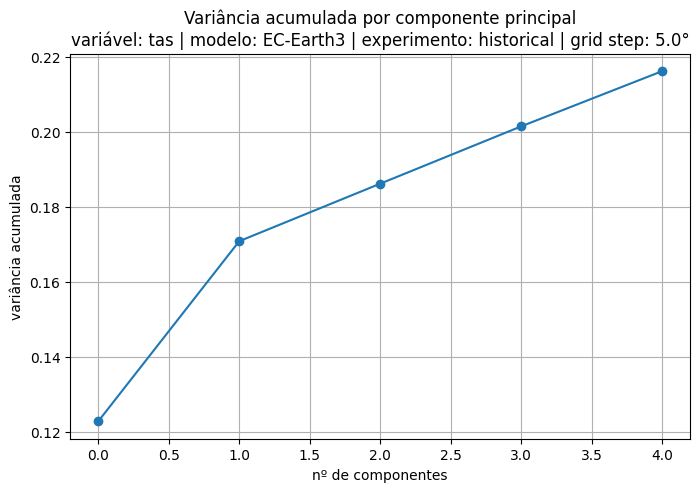

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("nº de componentes")
plt.ylabel("variância acumulada")
plt.title(f"Variância acumulada por componente principal\nvariável: {variable_id} | modelo: {input_model} | experimento: {input_experiment_id} | grid step: {grid_step}°")
plt.grid(True)
plt.show()

2025-09-03 19:45:34 -0300 | transformacao_dados | INFO | df_resampled_ex construído | 100 partições


2025-09-03 19:46:42 -0300 | transformacao_dados | INFO | df_flatten_ex construído | 100 partições


25/09/03 19:46:27 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


2025-09-03 19:46:28 -0300 | transformacao_dados | INFO | df_std construído | 100 partições
2025-09-03 19:46:28 -0300 | transformacao_dados | INFO | std_values construído | 252 pontos de grade
2025-09-03 19:46:28 -0300 | transformacao_dados | INFO | coords, lats, lons, stds construídos


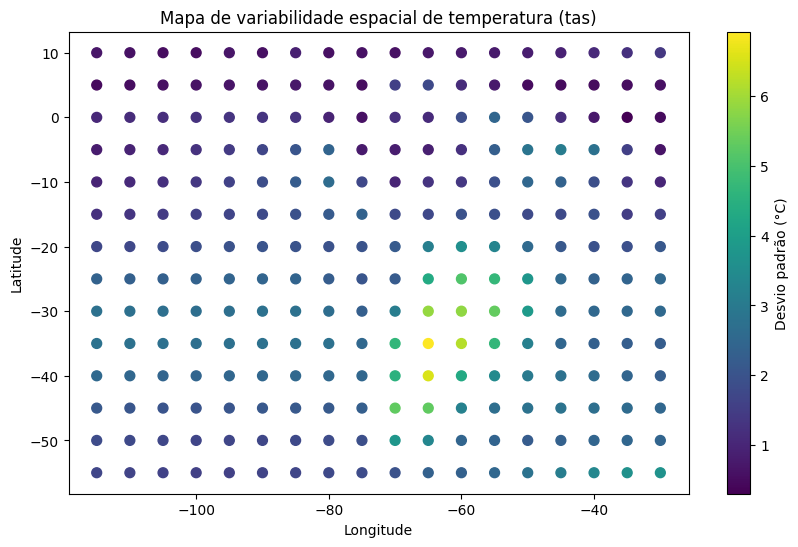

2025-09-03 19:46:29 -0300 | transformacao_dados | INFO | gráfico construído


In [62]:
from pyspark.sql.functions import stddev, col
import matplotlib.pyplot as plt
import numpy as np

# 1. Construir o df_flatten_ex (pivot)
df_resampled_ex = df_resampled.withColumn("lat_lon", concat_ws("_", col("lat_grid"), col("lon_grid")))
df_resampled_ex = df_resampled_ex.repartition(100)
logger_transform.info(f"df_resampled_ex construído | {df_resampled_ex.rdd.getNumPartitions()} partições")

pivot_values_ex = [row["lat_lon"] for row in df_resampled_ex.select("lat_lon").distinct().collect()]

df_flatten_ex = (
    df_resampled_ex
    .groupBy("year", "month")
    .pivot("lat_lon", values=pivot_values_ex)
    .agg(avg("tas_mean"))
)
df_flatten_ex = df_flatten_ex.repartition(100)
logger_transform.info(f"df_flatten_ex construído | {df_flatten_ex.rdd.getNumPartitions()} partições")

# 2. Identificar as colunas de gridpoint
grid_cols = [c for c in df_flatten_ex.columns if c not in ["year", "month"]]

# 3. Calcular o desvio padrão para cada gridpoint
df_std = df_flatten_ex.select(
    *[stddev(col(f"`{c}`")).alias(c) for c in grid_cols]
)
df_std = df_std.repartition(100)
logger_transform.info(f"df_std construído | {df_std.rdd.getNumPartitions()} partições")

# 4. Coletar resultados no driver
std_values = df_std.collect()[0].asDict()
logger_transform.info(f"std_values construído | {len(std_values)} pontos de grade")

# 5. Extrair coordenadas e valores
coords = [c.split("_") for c in std_values.keys()]
lats = np.array([float(lat) for lat, lon in coords])
lons = np.array([float(lon) for lat, lon in coords])
stds = np.array(list(std_values.values()))

logger_transform.info(f"coords, lats, lons, stds construídos")

# 6. Plotar o heatmap
plt.figure(figsize=(10, 6))
sc = plt.scatter(lons, lats, c=stds, cmap="viridis", s=50)
plt.colorbar(sc, label="Desvio padrão (°C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mapa de variabilidade espacial de temperatura (tas)")
plt.show()

logger_transform.info(f"gráfico construído")

In [71]:
n_rows = pca_model.pc.numRows
n_cols = pca_model.pc.numCols
print(f"PCA gerou uma matriz de {n_rows} linhas e {n_cols} colunas.")

PCA gerou uma matriz de 252 linhas e 5 colunas.


In [45]:
df_std.rdd.getNumPartitions()

1

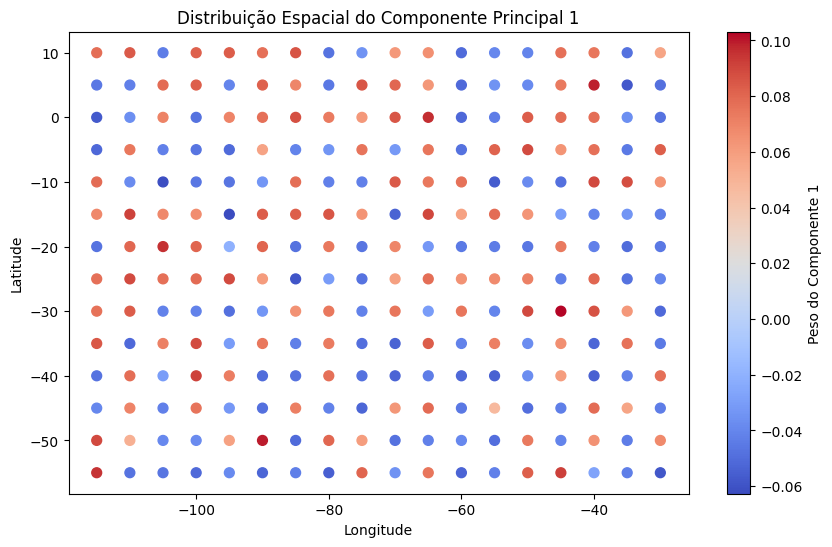

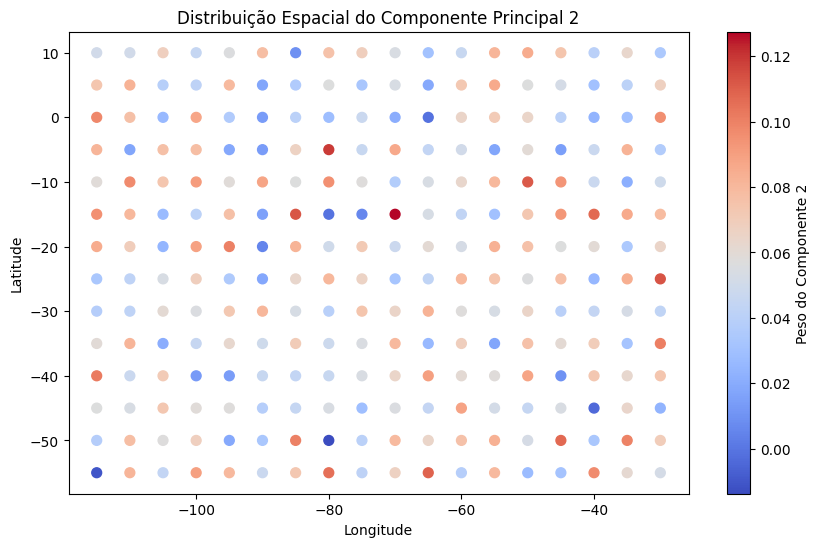

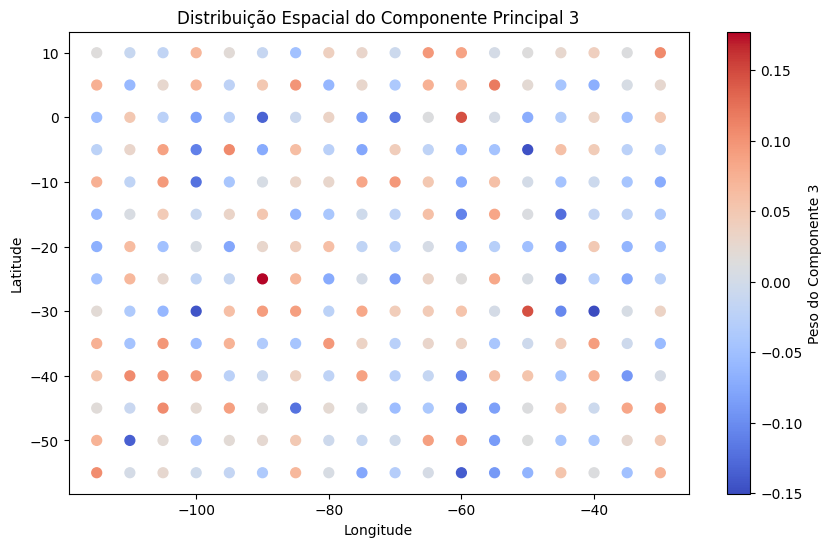

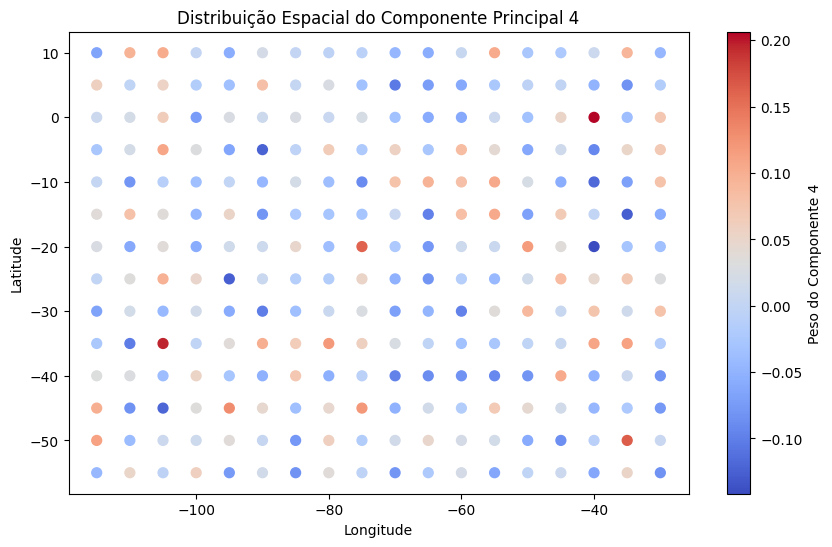

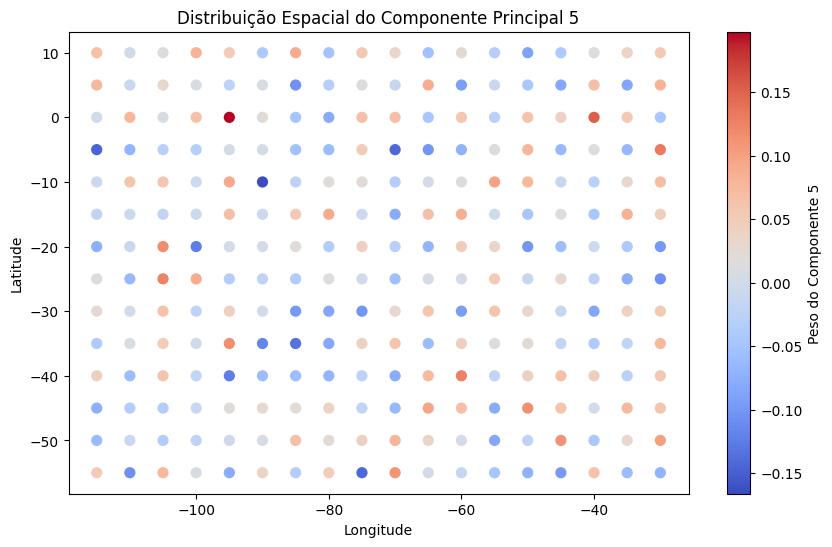

IndexError: index 5 is out of bounds for axis 1 with size 5

In [75]:
# Se você fez PCA só com as colunas de grid, use essas mesmas colunas
pca_grid_cols = grid_cols  # ou substitua pelo nome da lista que você usou no PCA

# 1. Pegando a matriz de componentes (loadings) do PCA
pc_loadings = pca_model.pc.toArray()  # shape: (n_components, n_gridpoints)

# 2. Extraindo apenas as coordenadas das colunas do PCA
coords = [c.split("_") for c in pca_grid_cols]
lats = np.array([float(lat) for lat, lon in coords])
lons = np.array([float(lon) for lat, lon in coords])

def plot_pca_component(component_idx):
    weights = pc_loadings[:, component_idx]
    if weights.shape[0] != lats.shape[0]:
        raise ValueError(
            f"Número de pesos ({weights.shape[0]}) não bate com número de pontos ({lats.shape[0]})"
        )
    plt.figure(figsize=(10, 6))
    sc = plt.scatter(lons, lats, c=weights, cmap="coolwarm", s=50)
    plt.colorbar(sc, label=f"Peso do Componente {component_idx+1}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Distribuição Espacial do Componente Principal {component_idx+1}")
    plt.show()

# 6. Plotando
for i in range(pc_loadings.shape[0]):
    plot_pca_component(i)

In [54]:
df_flatten_ex.rdd.getNumPartitions()

1

In [52]:
df_resampled.rdd.getNumPartitions()

1

In [22]:
df_vector_ready.show(5)

+----+-----+--------------------+
|year|month|           grid_list|
+----+-----+--------------------+
|1850|    1|[22.6287414550781...|
|1850|    2|[23.2523394775390...|
|1850|    3|[10.96212890625, ...|
|1850|    4|[9.88670989990234...|
|1850|    5|[8.71011788504464...|
+----+-----+--------------------+
only showing top 5 rows


In [ ]:
# 4. Opcional: definindo coluna alvo para LASSO com base em média, max, min
if lasso_target_strategy == "mean":
    df_vector = df_vector.withColumn("lasso_target", expr("aggregate(grid_list, 0D, (acc, x) -> acc + x) / size(grid_list)"))
elif lasso_target_strategy == "max":
    df_vector = df_vector.withColumn("lasso_target", expr("aggregate(grid_list, -1D/0D, (acc, x) -> IF(x > acc, x, acc))"))
elif lasso_target_strategy == "min":
    df_vector = df_vector.withColumn("lasso_target", expr("aggregate(grid_list, 1D/0D, (acc, x) -> IF(x < acc, x, acc))"))
else:
    raise ValueError(f"valor inválido para lasso_target_strategy: {lasso_target_strategy}")

# 5. Aplicando PCA no vetor
if apply_pca_flag:
    pca = PCA(k=n_pca_components, inputCol="features", outputCol="pca_features")
    pca_model = pca.fit(df_vector)
    df_vector = pca_model.transform(df_vector)

# 6. LASSO seria aplicado sobre "features" ou "pca_features"
if apply_lasso_flag:
    # Aqui entraria o código de LASSO do Spark
    pass

#### complexidade

In [ ]:
# measure_complexity_spark.py

import os
from pyspark.sql import SparkSession

#spark = SparkSession.builder.appName("ComplexityMeasure").getOrCreate()

def get_complexity_stats(df_spark, name, path):
    """Retorna estatísticas de complexidade de um DataFrame Spark."""
    # Contagem de linhas e colunas
    rows = df_spark.count()
    cols = len(df_spark.columns)
    
    # Tamanho real no disco (MB)
    size_bytes = sum(
        os.path.getsize(os.path.join(path, f))
        for f in os.listdir(path)
        if f.endswith(".parquet")
    )
    size_mb = size_bytes / (1024**2)
    
    return (name, rows, cols, size_mb)

def measure_all_stages(raw_dir, trusted_dir, delivery_dir, delivery_pca_lasso_dir):
    results = []
    
    # Raw
    df_raw = spark.read.parquet(raw_dir)
    results.append(get_complexity_stats(df_raw, "Raw", raw_dir))

    # Trusted
    df_trusted = spark.read.parquet(trusted_dir)
    results.append(get_complexity_stats(df_trusted, "Trusted", trusted_dir))

    # Delivery (sem PCA/LASSO)
    df_delivery = spark.read.parquet(delivery_dir)
    results.append(get_complexity_stats(df_delivery, "Delivery sem PCA/LASSO", delivery_dir))

    # Delivery (com PCA/LASSO)
    df_delivery_pca_lasso = spark.read.parquet(delivery_pca_lasso_dir)
    results.append(get_complexity_stats(df_delivery_pca_lasso, "Delivery com PCA/LASSO", delivery_pca_lasso_dir))

    # Criar DataFrame Spark com os resultados
    df_results = spark.createDataFrame(
        results,
        schema=["dataset", "rows", "cols", "size_mb"]
    )
    return df_results

if __name__ == "__main__":
    base_dir = "datasets"
    model = "ec_earth3"
    variable = "tas"

    raw_dir = dir_modelo_raw #f"{base_dir}/raw/{model}/{variable}"
    trusted_dir = dir_modelo_trusted #f"{base_dir}/trusted/{model}/{variable}"
    delivery_dir = dir_modelo_delivery #f"{base_dir}/delivery/{model}/{variable}"
    delivery_pca_lasso_dir = f"{base_dir}/delivery_pca_lasso/{model}/{variable}"

    df_metrics = measure_all_stages(raw_dir, trusted_dir, delivery_dir, delivery_pca_lasso_dir)

    # Mostrar na tela
    df_metrics.show(truncate=False)

    # Salvar métricas em uma nova camada
    metrics_dir = f"{base_dir}/metrics/{model}/{variable}"
    df_metrics.write.mode("overwrite").parquet(metrics_dir)
    print(f"Métricas salvas em {metrics_dir}")


In [27]:
# delivery_metrics.py
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, size as spark_size

#spark = SparkSession.builder.appName("DeliveryComplexityMeasure").getOrCreate()

def _parquet_dir_size_mb(path):
    """Soma tamanho dos arquivos .parquet em path (em MB). Se path não existir retorna 0."""
    if not os.path.exists(path):
        return 0.0
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(".parquet") or f.endswith(".parquet.snappy") or f.endswith(".snappy.parquet"):
                total += os.path.getsize(os.path.join(root, f))
    return total / (1024**2)

def measure_complexity_for_path(path):
    """
    Lê o parquet no path (se existir) e retorna um dicionário com métricas.
    Métricas custam uma leitura (count()).
    """
    if not os.path.exists(path):
        return {
            "path": path,
            "exists": False,
            "rows": 0,
            "cols": 0,
            "size_mb": 0.0,
            "avg_row_bytes": 0.0,
            "has_features_col": False,
            "n_features": None
        }

    # tenta ler
    try:
        df = spark.read.parquet(path)
    except Exception as e:
        return {
            "path": path,
            "exists": True,
            "read_error": str(e)
        }

    rows = df.count()
    cols = len(df.columns)
    size_mb = _parquet_dir_size_mb(path)
    avg_row_bytes = (size_mb * 1024**2 / rows) if rows > 0 else 0.0

    # detecta se tem coluna 'features' (Vector) ou 'grid_list' (array)
    has_features = "features" in df.columns
    n_features = None
    if has_features:
        # tenta obter o tamanho do vetor (size of vector/array). usa vector_to_array se necessário
        try:
            # se for vetor spark.ml.linalg.Vector, convertendo para array custa pouco
            # pega o primeiro valor de tamanho (assume consistente)
            # aqui usamos expressão size(features) se for array, senão tentamos vector_to_array length (via selectExpr)
            # preferimos selectExpr para não depender de imports locais
            n_features = int(df.selectExpr("size(vector_to_array(features)) as n").limit(1).collect()[0]["n"])
        except Exception:
            # fallback: se houver grid_list
            if "grid_list" in df.columns:
                n_features = int(df.selectExpr("size(grid_list) as n").limit(1).collect()[0]["n"])
            else:
                n_features = None

    return {
        "path": path,
        "exists": True,
        "rows": rows,
        "cols": cols,
        "size_mb": size_mb,
        "avg_row_bytes": avg_row_bytes,
        "has_features_col": has_features,
        "n_features": n_features
    }

def measure_delivery_complexity(base_output_dir, model, variable, experiments=None,
                                pca_flags=(False, True), lasso_flags=(False, True),
                                save_metrics_path=None):
    """
    Varre combinações exp / pca / lasso e mede complexidade dos datasets.
    base_output_dir: diretório base onde você salva a delivery (o mesmo que você usa em process_variable_delivery)
    model, variable: strings
    experiments: lista de experiment ids (se None, tenta detectar dirs dentro de base)
    retorna um DataFrame Spark com as métricas.
    """
    results = []

    # se não vier experiments, tenta listar diretórios em base_output_dir/model/variable
    model_var_base = os.path.join(base_output_dir, model, variable)
    if experiments is None:
        experiments = []
        if os.path.exists(model_var_base):
            for entry in os.listdir(model_var_base):
                if entry.startswith("exp="):
                    experiments.append(entry.split("exp=")[-1])
    if not experiments:
        # se não encontrou nada, considera uma lista padrão com None para medir path sem exp
        experiments = [None]

    for exp in experiments:
        for pca in pca_flags:
            for lasso in lasso_flags:
                # monta path igual ao que você usa no pipeline:
                # output_dir / exp=<exp> / pca=<pca> / lasso=<lasso>
                if exp is None:
                    path = os.path.join(base_output_dir, model, variable, f"pca={pca}", f"lasso={lasso}")
                else:
                    path = os.path.join(base_output_dir, model, variable, f"exp={exp}", f"pca={pca}", f"lasso={lasso}")
                stats = measure_complexity_for_path(path)
                stats.update({
                    "model": model,
                    "variable": variable,
                    "experiment": exp,
                    "pca": pca,
                    "lasso": lasso
                })
                results.append(stats)

    # criar DataFrame Spark dos resultados
    # normaliza keys
    all_keys = set()
    for r in results:
        all_keys.update(r.keys())
    schema_cols = sorted(list(all_keys))

    # turn list of dicts into list of tuples in same order
    rows = []
    for r in results:
        rows.append(tuple(r.get(k, None) for k in schema_cols))

    df_metrics = spark.createDataFrame(rows, schema=schema_cols)

    if save_metrics_path:
        os.makedirs(os.path.dirname(save_metrics_path), exist_ok=True)
        df_metrics.write.mode("overwrite").parquet(save_metrics_path)

    return df_metrics


In [29]:
delivery_dir

'/home/thais/climate-ingestion/climate_data_processing/datasets/delivery/ec_earth3/tas'

In [30]:
raw_dir = dir_modelo_raw #f"{base_dir}/raw/{model}/{variable}"
trusted_dir = dir_modelo_trusted #f"{base_dir}/trusted/{model}/{variable}"
delivery_dir = dir_modelo_delivery #f"{base_dir}/delivery/{model}/{variable}"

base_output_dir = "/home/thais/climate-ingestion/climate_data_processing/datasets/delivery"   # onde você grava os dados na pipeline
df_metrics = measure_delivery_complexity(base_output_dir, "ec_earth3", "tas", save_metrics_path=f"{base_output_dir}/ec_earth3/tas/_metrics.parquet")
df_metrics.show(truncate=False)

PySparkValueError: [CANNOT_DETERMINE_TYPE] Some of types cannot be determined after inferring.